# SEAVEA Introductory Tutorial


The **SEAVEA** (see-vee-uh) Toolkit is an open-source framework that supports **Verification, Validation, and Uncertainty Quantification (VVUQ)** for scientific computing applications. It provides a collection of interoperable tools that help researchers design, execute, and analyse computational experiments at scale, from local machines to High-Performance Computing (HPC) environments.

By combining workflow automation, uncertainty quantification, ensemble execution, and surrogate modelling capabilities, SEAVEA enables researchers to conduct complex simulation studies in a reproducible and efficient manner. The toolkit has been developed to support a wide range of scientific domains, including:

* Climate Science
* Fusion Energy
* Epidemiology
* Migration Modelling
* Aerospace Engineering
* Medicine

<p align="center">
    <img src="image.png" width="70%">
</p>

<p align="center">
    <strong>Figure 1.</strong> High-level architecture of the SEAVEA toolkit showing the interaction between local computing resources, HPC systems, workflow automation, uncertainty quantification, and simulation execution tools.
</p>

Figure 1 provides an overview of the SEAVEA ecosystem and how its components work together to support scientific computing workflows. The architecture is divided into a **Local Processing Environment** (left) and an **HPC Processing Environment** (right).

Within the local environment, researchers define simulation experiments, configure uncertain parameters, and perform uncertainty quantification using tools such as **EasyVVUQ**. **FabSim3** acts as the central workflow automation framework, coordinating simulation execution, managing files, and connecting local resources to remote HPC systems.

For large-scale simulation studies, workflows can be executed on HPC resources using **QCG-PilotJob** or **RADICAL-Pilot**, which efficiently manage large ensembles of simulation tasks within a single HPC allocation. These tasks are then scheduled and executed on the HPC cluster.

The broader SEAVEA ecosystem also includes additional components for surrogate modelling (EasySurrogate, MOGP Emulator), multiscale model coupling (MUSCLE3), uncertainty quantification portals (mUQSA), and visualisation (FUMEplot). These components are included in the architecture diagram to illustrate the full capabilities of SEAVEA; however, they are outside the scope of this introductory tutorial. 

## Components Used in this Tutorial

This tutorial focuses on the workflow formed by **EasyVVUQ**, **FabSim3**, and **QCG-PilotJob**, which together enable researchers to define uncertainty studies, automate simulation execution, and efficiently run large ensembles on local or HPC resources.


| Component        | Description                                                                                                                                              |
| ---------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **EasyVVUQ**     | Defines uncertain parameters, generates samples, manages simulation campaigns, and performs uncertainty quantification and sensitivity analysis.         |
| **FabSim3**      | Automates workflow execution, file transfer, and job management across local and HPC systems.                                                            |
| **QCG-PilotJob** | Efficiently executes large ensembles of simulation tasks within a single HPC allocation, reducing scheduler overhead and improving resource utilisation. |

## Environment Set-up Instructions

### Prerequisites

Before running this notebook:

- Create a Python 3.10 virtual environment.
- Install `requirements.txt`.
- Install and configure FabSim3, including creation of `machines_user.yml`.
- Install Flee and the FabFlee plugin.
- Confirm that the Mali configuration is available.

> This notebook uses Bash cells and must be run in Linux, WSL, Git Bash,
> Colab, or a Linux-based Jupyter environment.

### Links

Please refer to the following links for the corresponding components setup to be able to follow this tutorial.

FabSim3 installation (The installation process creates the
required fabsim/deploy/machines_user.yml file) - https://fabsim3.readthedocs.io/en/latest/installation/
<br>
EasyVVUQ installation - https://easyvvuq.readthedocs.io/en/dev/installation.html#id1
<br>
QCG-PilotJob installation - https://qcg-pilotjob.readthedocs.io/en/develop/installation.html
<br>
Flee installation - https://flee.readthedocs.io/en/master/Installation_and_Testing/
<br>
FabFlee Plugin - https://fabsim3.readthedocs.io/en/latest/plugins/


## Tutorial Problem Focus

This tutorial demonstrates how the SEAVEA components work together to support the simulation, validation, uncertainty quantification, and efficient execution of forced-migration models.

The primary demonstration uses the **Mali conflict scenario**, with additional examples from **Burundi, South Sudan, and the Central African Republic**.

The tutorial covers:

- Simulating refugee movements and camp populations using Flee.
- Automating simulation workflows and result collection with FabSim3.
- Comparing predicted camp populations with historical UNHCR data.
- Automatically validating multiple conflict scenarios.
- Investigating uncertain movement assumptions, including `max_move_speed` and `max_walk_speed`.
- Measuring total prediction error.
- Calculating Sobol sensitivity indices with EasyVVUQ.
- Executing simulation ensembles concurrently with QCG-PilotJob.

Together, these components provide an integrated workflow for examining how modelling assumptions affect forced-migration predictions while reducing the effort and computational cost of running large simulation ensembles.

# FabSim3 Introduction

### 1. Verify the configured `machines_user.yml` file

FabSim3 uses this machine-specific file to locate its execution environment, input configurations, and results directories. The following cell checks that it was created during FabSim3 installation.

In [2]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
MACHINES_FILE="$FABSIM_ROOT/fabsim/deploy/machines_user.yml"

if [ ! -f "$MACHINES_FILE" ]; then
    echo "Error: FabSim3 is not configured. Complete the linked installation guide."
    exit 1
fi

echo "FabSim3 configuration found: $MACHINES_FILE"

FabSim3 configuration found: /home/anany/github/FabSim3/fabsim/deploy/machines_user.yml


### 2. Migration Modelling with the FabFlee Plugin

[FabFlee](https://github.com/djgroen/FabFlee) connects FabSim3 to
[Flee](https://flee.readthedocs.io/en/latest/), an agent-based model for
simulating the movement of displaced people between geographical locations.

FabFlee automates the preparation, execution, collection, validation, and
visualisation of Flee simulations. In this tutorial, it is used to run the
Mali conflict scenario and compare simulated refugee-camp populations with
historical UNHCR data.

> FabFlee should be installed before the webinar. The standard FabSim3
> command is:
>
> ```bash
> fabsim localhost install_plugin:FabFlee
> ```
>
> Refer to the setup guide for operating-system-specific instructions.

In [7]:
%%bash
fabsim localhost install_plugin:FabFlee

[Executing task] install_plugin
[local] mkdir -p /home/anany/github/FabSim3/plugins
[local] rm -rf /home/anany/github/FabSim3/plugins/FabFlee
[local] git clone https://github.com/djgroen/FabFlee.git '/home/anany/github/FabSim3/plugins/FabFlee'


Cloning into '/home/anany/github/FabSim3/plugins/FabFlee'...
Updating files: 100% (2502/2502), done.


FabFlee plugin installed...
No requirements.txt file found for FabFlee plugin
No additional Python packages were installed for this plugin.
Plugin FabFlee installed successfully.


### 3. Verify Flee and FabFlee

This check confirms that the Flee model and its FabSim3 plugin are available before any simulation is launched.

Expected folder layout (recommended):

```text
parent-folder/
├── SEAVEA-tutorials/
├── FabSim3/
└── flee/
```

The verification cell uses one directory above the notebook working directory (`../`) as the parent folder. If your repositories are stored in a different location, update the paths in the cell accordingly.

In [1]:
%%bash
set -e

ROOT="$(cd .. && pwd)"
FLEE_ROOT="$ROOT/flee"
FABFLEE_ROOT="$ROOT/FabSim3/plugins/FabFlee"

if [ -d "$FLEE_ROOT" ]; then
    echo "Flee found: $FLEE_ROOT"
else
    echo "Flee not found: $FLEE_ROOT"
    exit 1
fi

if [ -d "$FABFLEE_ROOT" ]; then
    echo "FabFlee plugin found: $FABFLEE_ROOT"
else
    echo "FabFlee plugin not found: $FABFLEE_ROOT"
    exit 1
fi

Flee found: /home/anany/github/flee
FabFlee plugin found: /home/anany/github/FabSim3/plugins/FabFlee


### 4. Inspect the Mali Scenario

The Mali configuration contains the migration network, conflict data, camp locations, simulation settings, and historical observations used for validation.

In [3]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"

MALI_SCENARIO="mali2012"
MALI_CONFIG="$FABSIM_ROOT/plugins/FabFlee/config_files/$MALI_SCENARIO"

[ -d "$MALI_CONFIG" ] || { echo "Error: Mali configuration was not found at $MALI_CONFIG"; exit 1; }

echo "Mali configuration: $MALI_CONFIG"
find "$MALI_CONFIG" -maxdepth 2 -type f | sed -n '1,20p'

Mali configuration: /home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/simsetting.yml
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/demographics_ethnicity.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/closures.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/conflicts.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/locations.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/demographics_gender.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/demographics_age.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/routes.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/sim_period.csv
/home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/input_csv/registration_correcti

### 5. Run a Baseline Mali Simulation

There are 4 different ways to execute multiscale migration simulations in FabFlee:

* Single-model execution
<br>
* Ensemble execution
<br>
* Replica execution
<br>
* Coupled execution

Each method has its unique purpose. The single-model execution can be easily performed on a laptop and instantly provide an overview to users. The ensemble execution may be useful for those who run multiple simulation instances simultaneously. The replica execution could be an interesting option for those who run simulations at once with identical inputs for analysis. The coupled execution can couple migration simulation with conflict evolution models in the context of multiscale uncertainty quantification (UQ).

#### Purposes of Demonstration

To execute FabFlee job on a localhost, execute one of the conflict instances using `flee` function in `FabSim3/plugins/FabFlee/config_files`, such as Mali (mali, simulation period of 300 days), Burundi (burundi, simulation period of 396 days), South Sudan (ssudan, simulation period of 604 days) and Central African Republic (car, simulation period of 820 days). 

For illustration purposes, the conflict scenario of Mali is executed to obtain the simulation output for a simulation period of 50 days, which can be changed up to 300 days.

In [5]:
%%bash

fabsim localhost sflee:mali2012,simulation_period=50

[loading plugin] FabFlee ...
Error: failed to import settings module flee_vis
<class 'ModuleNotFoundError'>
ModuleNotFoundError("No module named 'flee'")


  File "/home/anany/github/FabSim3/plugins/FabFlee/FabFlee.py", line 1072, in <module>
    from plugins.FabFlee.vis.flee_geo import *
  File "/home/anany/github/FabSim3/plugins/FabFlee/vis/flee_geo.py", line 9, in <module>
    import flee.InputGeography


The FabFlee flee_vis functionalities are not imported as a result.
[Executing task] sflee
calling task sflee from plugin FabFlee

NO machines_FabFlee_user.yml FOUND

[local] ssh -Y -p 22 anany@localhost 'mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/config_files; mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/results; mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/scripts; mkdir -p /home/anany/github/FabSim3/localhost_exe/FabSim/config_files/mali2012'


[local] rsync -pthrvz /home/anany/github/FabSim3/plugins/FabFlee/config_files/mali2012/ anany@localhost:/home/anany/github/FabSim3/localhost_exe/FabSim/config_files/mali2012/
sending incremental file list

sent 1.15K bytes  received 18 bytes  2.34K bytes/sec
total size is 152.99K  speedup is 130.54
[MultiProcessingPool] Starting Process child : Name = ForkPoolWorker-1 Process-1:1 , PID = 7065,  parentPID = 6943 Max PoolSize = 15 requested PoolSize = 4
[MultiProcessingPool] Starting Process child : Name = ForkPoolWorker-2 Process-2:1 , PID = 7066,  parentPID = 6943 Max PoolSize = 15 requested PoolSize = 4
[MultiProcessingPool] Starting Process child : Name = ForkPoolWorker-3 Process-3:1 , PID = 7067,  parentPID = 6943 Max PoolSize = 15 requested PoolSize = 4
[MultiProcessingPool] Starting Process child : Name = ForkPoolWorker-4 Process-4:1 , PID = 7068,  parentPID = 6943 Max PoolSize = 15 requested PoolSize = 4
╭──────── job preparation phase ────────╮
│ tmp_work_path = /tmp/s0tcrrq_/Fa

sending incremental file list

sent 1.15K bytes  received 18 bytes  2.33K bytes/sec
total size is 152.99K  speedup is 131.55


YAML file: simsetting.yml
YAML: {'log_levels': {'agent': 1, 'camp': 0, 'init': 0, 'link': 1, 'conflict': 0, 'granularity': 'location'}, 'spawn_rules': {'take_from_population': False, 'conflict_spawn_decay': [1.0, 1.0, 1.0, 0.5, 0.1], 'insert_day0': True}, 'move_rules': {'max_move_speed': 200.0, 'max_walk_speed': 35.0, 'foreign_weight': 1.0, 'camp_weight': 5.0, 'awareness_level': 1, 'capacity_buffer': 0.75, 'conflict_weight': 0.25, 'conflict_movechance': 1.0, 'camp_movechance': 0.001, 'default_movechance': 0.3, 'capacity_scaling': 1.0, 'avoid_short_stints': False, 'start_on_foot': False, 'weight_power': 1.0}, 'optimisations': {'hasten': 10}}
Take from population? False
Spawn decay set to: [1.0, 1.0, 1.0, 0.5, 0.1], with interval 30
INFO: Fixed Route Generation for Locations: False
Move rules set to: {'FloodRulesEnabled': False, 'FloodForecaster': False, 'flood_forecaster_timescale': 0, 'MaxMoveSpeed': 200.0, 'MaxWalkSpeed': 35.0, 'MaxCrossingSpeed': 20.0, 'ForeignWeight': 1.0, 'CampWeig

Use fabsim localhost fetch_results to copy the results back to local machine!
submitted job script = 
['/home/anany/github/FabSim3/localhost_exe/FabSim/results/mali2012_localhost_1/mali2012_localhost_1.sh']


#### Fetching the simulation results to `FabSim3/results` directory

After the job has finished, a message will be printed indicating where the output data resides. To fetch and copy the obtained results to `FabSim3/results` directory, simply execute:

In [6]:
%%bash
fabsim localhost fetch_results

[loading plugin] FabFlee ...
Error: failed to import settings module flee_vis
<class 'ModuleNotFoundError'>
ModuleNotFoundError("No module named 'flee'")


  File "/home/anany/github/FabSim3/plugins/FabFlee/FabFlee.py", line 1072, in <module>
    from plugins.FabFlee.vis.flee_geo import *
  File "/home/anany/github/FabSim3/plugins/FabFlee/vis/flee_geo.py", line 9, in <module>
    import flee.InputGeography


The FabFlee flee_vis functionalities are not imported as a result.
[Executing task] fetch_results
[local] rsync -pthrvz -e 'ssh -p 22' anany@localhost:/home/anany/github/FabSim3/localhost_exe/FabSim/results// /home/anany/github/FabSim3/results/
receiving incremental file list
./
mali2012_localhost_1/
mali2012_localhost_1/agents.out.0
mali2012_localhost_1/env.log
mali2012_localhost_1/env.yml
mali2012_localhost_1/links.out.0
mali2012_localhost_1/mali2012_localhost_1.sh
mali2012_localhost_1/out.csv

sent 20.55K bytes  received 708.57K bytes  486.08K bytes/sec
total size is 10.74M  speedup is 14.74


### 6. Plotting the simulation output

After fetching the simulation results, analyse and interpret simulation output by plotting graphs for individual camps comparing simulation output and UNHCR data, as well as average relative difference graph for the simulated conflict situation.

In [7]:
%%bash

cd FabSim3

fabsim localhost plot_output:mali2012_localhost_1,out

[loading plugin] FabFlee ...
Error: failed to import settings module flee_vis
<class 'ModuleNotFoundError'>
ModuleNotFoundError("No module named 'flee'")


  File "/home/anany/github/FabSim3/plugins/FabFlee/FabFlee.py", line 1072, in <module>
    from plugins.FabFlee.vis.flee_geo import *
  File "/home/anany/github/FabSim3/plugins/FabFlee/vis/flee_geo.py", line 9, in <module>
    import flee.InputGeography


The FabFlee flee_vis functionalities are not imported as a result.
[Executing task] plot_output
calling task plot_output from plugin FabFlee

NO machines_FabFlee_user.yml FOUND

[local] mkdir -p /home/anany/github/FabSim3/results/mali2012_localhost_1/out
mali2012 - single-scale model: Averaged error normal:  0.4465784546912194 , rescaled:  0.279751840508146 , len:  50
The results of Serial mode simulation are stored in /home/anany/github/FabSim3/results/mali2012_localhost_1/out directory.


To list generated plots, run the following command

In [15]:
%%bash
RESULT_DIR=$(ls -dt /home/anany/github/FabSim3/results/mali2012_localhost_* | head -n 1)

echo "Latest result: $RESULT_DIR"
find "$RESULT_DIR/out" -maxdepth 1 -type f

Latest result: /home/anany/github/FabSim3/results/mali2012_localhost_1


In [17]:
%%bash
RESULT_DIR=$(find /home/anany/github/FabSim3/results \
  -maxdepth 1 -type d -name "mali2012_localhost_*" \
  -printf "%T@ %p\n" | sort -nr | head -n 1 | cut -d" " -f2-)

echo "Result directory: $RESULT_DIR"
echo "Output contents:"
find "$RESULT_DIR/out" -type f

Result directory: /home/anany/github/FabSim3/results/mali2012_localhost_1
Output contents:
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Tabareybarey.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Mangaize.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Bobo-Dioulasso.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Fassala-Mbera.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Niamey.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Mentao.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Abala.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/numagents/numagents.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/errors/error_comparison.png
/home/anany/github/FabSim3/results/mali2012_localhost_1/out/errors/error.png


To view generated plots, simply run:

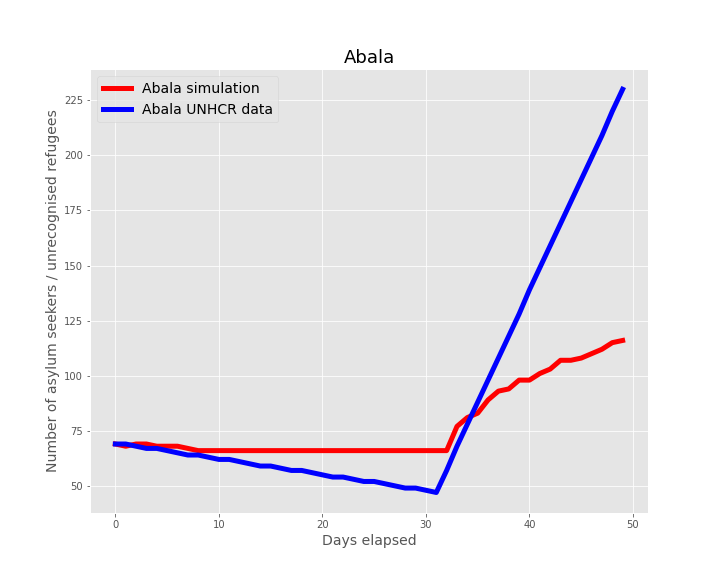

In [18]:
from IPython.display import Image 
Image('/home/anany/github/FabSim3/results/mali2012_localhost_1/out/camps/Abala.png') ## CHANGE TO GENERIC ONE

### 6. Compare Predictions with UNHCR Data

FabFlee compares simulated populations at individual camps with historical UNHCR observations. The generated plots show camp-level agreement and prediction error over time.

In [ ]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
cd "$FABSIM_ROOT"
LATEST_RESULT=$(ls -dt results/mali_localhost_* 2>/dev/null | head -n 1)
[ -n "$LATEST_RESULT" ] || { echo "Error: no fetched Mali result was found."; exit 1; }
RUN_NAME=$(basename "$LATEST_RESULT")
if [ -x ./VirtualEnv/Scripts/python.exe ]; then FABSIM_PYTHON=./VirtualEnv/Scripts/python.exe; else FABSIM_PYTHON=./VirtualEnv/bin/python; fi

echo "Plotting result: $RUN_NAME"
"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim localhost "plot_output:${RUN_NAME},out"

In [ ]:
from pathlib import Path
from IPython.display import Image, display

fabsim_root = (Path.cwd().parent / "FabSim3").resolve()
result_dirs = sorted((fabsim_root / "results").glob("mali_localhost_*"), key=lambda p: p.stat().st_mtime, reverse=True)
if not result_dirs:
    raise FileNotFoundError("No fetched Mali result was found.")

plots = list((result_dirs[0] / "out").rglob("*.png"))
print(f"Result directory: {result_dirs[0]}")
for plot in plots[:4]:
    print(plot.name)
    display(Image(filename=str(plot)))

### 7. Configure Uncertain Movement Parameters

The sensitivity study is controlled by `flee_SA_config.yml`. It specifies the varying Flee parameters, their distributions, the EasyVVUQ sampler, and polynomial order. This tutorial focuses on movement assumptions such as `max_move_speed` and `max_walk_speed`.

In [ ]:
from pathlib import Path
import yaml

fabsim_root = (Path.cwd().parent / "FabSim3").resolve()
sa_config_file = fabsim_root / "plugins" / "FabFlee" / "flee_SA_config.yml"
if not sa_config_file.exists():
    raise FileNotFoundError(f"Sensitivity configuration not found: {sa_config_file}")

with sa_config_file.open(encoding="utf-8") as stream:
    sa_config = yaml.safe_load(stream)

for key in ["sampler_name", "polynomial_order", "distribution_type", "selected_vary_parameters"]:
    print(f"{key}: {sa_config.get(key)}")

### 8. Execute the Sensitivity-Analysis Ensemble

EasyVVUQ generates uncertain parameter samples, while FabSim3 and FabFlee prepare and run one Flee simulation for each sample. This example uses a 30-day Mali simulation to keep the demonstration manageable.

In [ ]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
cd "$FABSIM_ROOT"
if [ -x ./VirtualEnv/Scripts/python.exe ]; then FABSIM_PYTHON=./VirtualEnv/Scripts/python.exe; else FABSIM_PYTHON=./VirtualEnv/bin/python; fi

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim localhost flee_init_SA:mali,simulation_period=30
"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim localhost fetch_results

### 9. Analyse Total Prediction Error and Sobol Indices

The analysis collates the ensemble, compares each run with historical observations, and calculates statistical moments and Sobol sensitivity indices for total prediction error. A larger first-order Sobol index means that uncertainty in that parameter explains a larger share of output variance.

In [ ]:
%%bash
set -e

FABSIM_ROOT="$(cd .. && pwd)/FabSim3"
cd "$FABSIM_ROOT"
if [ -x ./VirtualEnv/Scripts/python.exe ]; then FABSIM_PYTHON=./VirtualEnv/Scripts/python.exe; else FABSIM_PYTHON=./VirtualEnv/bin/python; fi

"$FABSIM_PYTHON" -X utf8 ./fabsim/bin/fabsim localhost flee_analyse_SA:mali

In [ ]:
from pathlib import Path
from IPython.display import Image, display

fabsim_root = (Path.cwd().parent / "FabSim3").resolve()
analysis_root = fabsim_root / "plugins" / "FabFlee"
analysis_plots = list(analysis_root.rglob("plot_*Total error*.png"))
if not analysis_plots:
    raise FileNotFoundError("No sensitivity-analysis plots were found.")

for plot in analysis_plots:
    print(plot)
    display(Image(filename=str(plot)))

### 10. QCG-PilotJob as an Ensemble-Execution Extension

Each EasyVVUQ sample is an independent Flee simulation. QCG-PilotJob can schedule these tasks concurrently within a local resource pool or an HPC allocation, reducing scheduler overhead for large ensembles.

The baseline FabFlee sensitivity workflow above remains the executable path in this introductory notebook. QCG-PilotJob is presented as an extension because its launch configuration depends on the available machine or HPC scheduler.

In [ ]:
from importlib.metadata import version

print(f"QCG-PilotJob version: {version('qcg-pilotjob')}")
print("QCG-PilotJob is available for configuring parallel ensemble execution.")

### 11. Additional Conflict Scenarios and Autovalidation

The same workflow can be applied to other supplied Flee scenarios:

| Scenario | Configuration | Reference simulation period |
| --- | --- | ---: |
| Mali | `mali` | 300 days |
| Burundi | `burundi` | 396 days |
| South Sudan | `ssudan` | 604 days |
| Central African Republic | `car` | 820 days |

FabFlee also provides `validate_flee` for validating multiple configured conflict scenarios. Because this can launch a substantial ensemble, it is documented rather than executed during the webinar:

```bash
fabsim localhost validate_flee
```

## Summary

This workflow uses Flee to model forced migration, FabSim3 and FabFlee to automate simulations and validation, and EasyVVUQ to quantify how movement assumptions influence prediction error. QCG-PilotJob provides a path to concurrent ensemble execution when the study is moved to larger local resources or HPC systems.